使用设备: cuda
类别: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
Train: 18400, Val: 2800, Test: 2800
SimpleOCTNet(
  (features): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)

Epoch 1/8
------------------------------
train Loss: 1.1325  Acc: 0.5114
val Loss: 0.8940  Acc: 0.6246

Epoch 2/8
------------------------------
train Loss: 0.8157  Acc: 0.6591
val Loss: 0.7874  Acc: 0.6729

Epoch 3/8
----------------------------

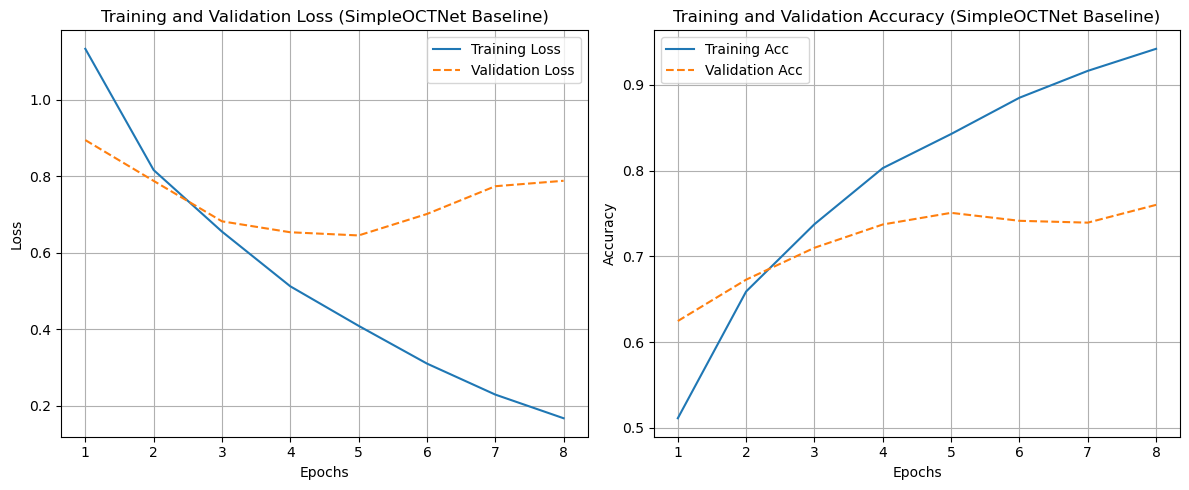


正在测试集上评估 SimpleOCTNet 基准模型...
测试集准确率 (SimpleOCTNet Baseline Test Acc): 74.04%

正在生成混淆矩阵（未归一化）...


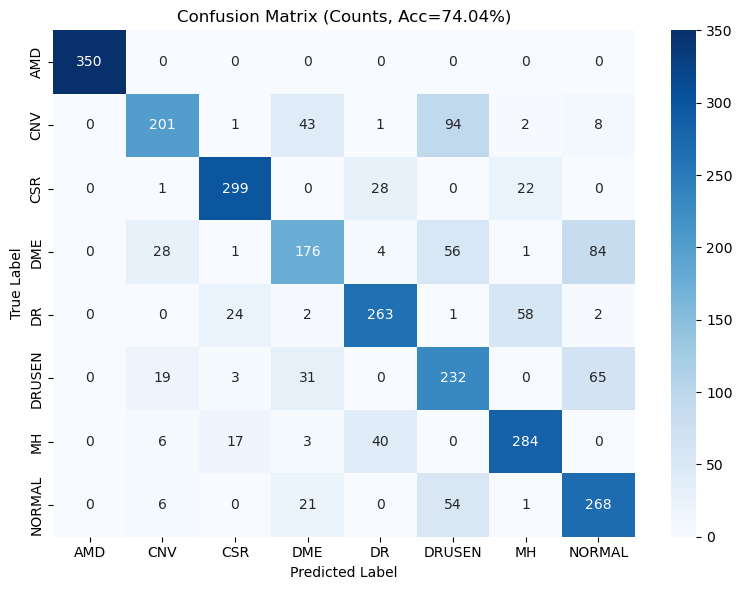

未归一化混淆矩阵已显示！


In [25]:
import os
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np


DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset'

BATCH_SIZE    = 32
LEARNING_RATE = 0.001
NUM_EPOCHS    = 8
IMG_SIZE      = 128
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"使用设备: {DEVICE}")

torch.manual_seed(42)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(42)


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5],
                             [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5],
                             [0.5, 0.5, 0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5],
                             [0.5, 0.5, 0.5])
    ]),
}

image_datasets = {}
dataloaders = {}

for split in ['train', 'val', 'test']:
    split_dir = os.path.join(DATA_DIR, split)
    if not os.path.exists(split_dir):
        print(f"错误: 找不到路径 {split_dir}，请检查 DATA_DIR 设置！")
        raise SystemExit

    image_datasets[split] = datasets.ImageFolder(split_dir, data_transforms[split])
    dataloaders[split] = DataLoader(
        image_datasets[split],
        batch_size=BATCH_SIZE,
        shuffle=(split == 'train'),
        num_workers=2
    )

class_names = image_datasets['train'].classes
num_classes = len(class_names)
print(f"类别: {class_names}")
print(f"Train: {len(image_datasets['train'])}, "
      f"Val: {len(image_datasets['val'])}, "
      f"Test: {len(image_datasets['test'])}")


class SimpleOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(SimpleOCTNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(4, 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 32 * 32, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 30)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            dataset_size = len(image_datasets[phase])
            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            print(f'{phase} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

    time_elapsed = time.time() - since
    print(f'\n训练完成! 耗时: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

if __name__ == '__main__':
    model = SimpleOCTNet(num_classes=num_classes).to(DEVICE)
    print(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    model, history = train_model(model, criterion, optimizer, NUM_EPOCHS)

    torch.save(model.state_dict(), 'oct_simple_cnn_baseline_45.pth')
    print("约 45% 的基准 CNN 模型已保存为 oct_simple_cnn_baseline_45.pth")

    # ---------- 绘制 Loss / Accuracy 曲线 ----------
    epochs_range = range(1, NUM_EPOCHS + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss (SimpleOCTNet Baseline)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Training Acc')
    plt.plot(epochs_range, history['val_acc'], label='Validation Acc', linestyle='--')
    plt.title('Training and Validation Accuracy (SimpleOCTNet Baseline)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n正在测试集上评估 SimpleOCTNet 基准模型...")
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100.0 * correct / total
    print(f'测试集准确率 (SimpleOCTNet Baseline Test Acc): {test_acc:.2f}%')

    print("\n正在生成混淆矩阵（未归一化）...")

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',                    
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f'Confusion Matrix (Counts, Acc={test_acc:.2f}%)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print("未归一化混淆矩阵已显示！")


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
import copy

DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset' 
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20 
IMG_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"使用设备: {DEVICE}")

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10), # 增加一点旋转
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
}

image_datasets = {}
dataloaders = {}
for x in ['train', 'val', 'test']:
    image_datasets[x] = datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
    dataloaders[x] = DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x=='train'), num_workers=4)

# ==========================================
# 3. 改进版的手写 CNN (MyCustomCNN)
# ==========================================
class ImprovedOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(ImprovedOCTNet, self).__init__()
        
        # 特征提取
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64
            
            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x32
            
            # Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 16x16
            
            # Layer 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 8x8
        )
        
        # 分类头 (改进点：移除巨大的全连接层，改用 GAP)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # 无论前面尺寸多少，强行压成 1x1
            nn.Flatten(),
            nn.Dropout(0.5), # 丢弃50%神经元，防止过拟合
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f'  {phase} Acc: {epoch_acc:.4f}')

            # 只保存最好的
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
    
    # 恢复最佳权重
    model.load_state_dict(best_model_wts)
    print(f'最佳验证集准确率: {best_acc:.4f}')
    return model


if __name__ == '__main__':
    model = ImprovedOCTNet(num_classes=8).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model = train_model(model, criterion, optimizer, NUM_EPOCHS)
    
    # 测试
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'测试集准确率: {100 * correct / total:.2f}%')

使用设备: cuda
Epoch 1/20
  train Acc: 0.5033
  val Acc: 0.3704
Epoch 2/20
  train Acc: 0.6779
  val Acc: 0.4639
Epoch 3/20
  train Acc: 0.7602
  val Acc: 0.5782
Epoch 4/20
  train Acc: 0.8104
  val Acc: 0.5261
Epoch 5/20
  train Acc: 0.8395
  val Acc: 0.7654
Epoch 6/20
  train Acc: 0.8582
  val Acc: 0.6889
Epoch 7/20
  train Acc: 0.8652
  val Acc: 0.7039
Epoch 8/20
  train Acc: 0.8805
  val Acc: 0.6957
Epoch 9/20
  train Acc: 0.8866
  val Acc: 0.7593
Epoch 10/20
  train Acc: 0.8943
  val Acc: 0.8439
Epoch 11/20
  train Acc: 0.9017
  val Acc: 0.7200
Epoch 12/20
  train Acc: 0.9070
  val Acc: 0.8429
Epoch 13/20
  train Acc: 0.9099
  val Acc: 0.9007
Epoch 14/20
  train Acc: 0.9146
  val Acc: 0.9118
Epoch 15/20
  train Acc: 0.9178
  val Acc: 0.9189
Epoch 16/20
  train Acc: 0.9238
  val Acc: 0.7761
Epoch 17/20
  train Acc: 0.9211
  val Acc: 0.8471
Epoch 18/20
  train Acc: 0.9269
  val Acc: 0.8714
Epoch 19/20
  train Acc: 0.9270
  val Acc: 0.8846
Epoch 20/20
  train Acc: 0.9343
  val Acc: 0.839

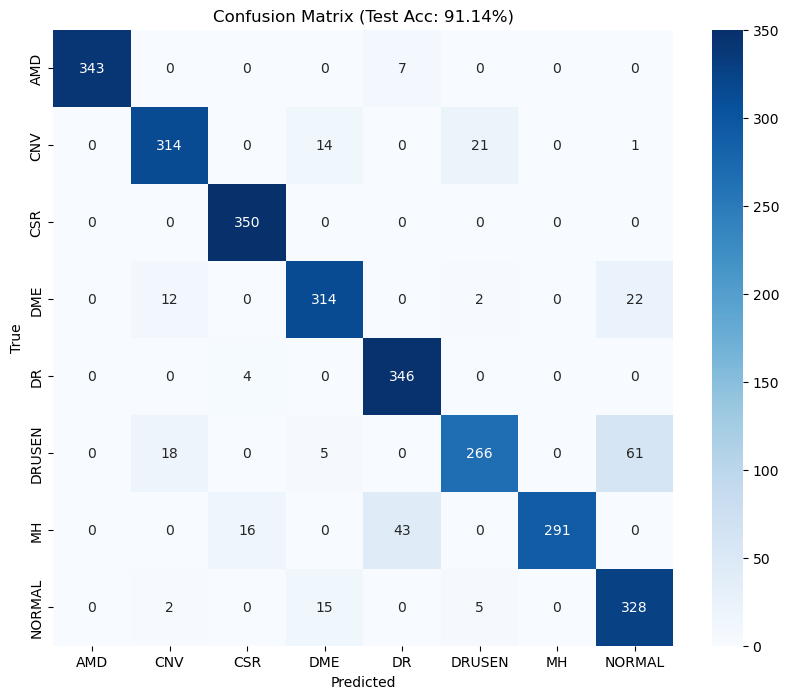

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 1. 获取所有预测结果
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))

# 3. 画热力图
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Acc: 91.14%)')
plt.show()

🚀 当前运行设备: cuda
   显卡型号: NVIDIA GeForce RTX 4050 Laptop GPU

📊 正在加载数据...
   -> train集: 找到 18400 张图片
   -> val  集: 找到 2800 张图片
   -> test 集: 找到 2800 张图片
✅ 检测到 8 个类别: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']

🏗️ 正在初始化 AttentionOCTNet 模型...
🔥 开始训练 (请耐心等待)...

Epoch 1/25
------------------------------
当前学习率 (LR): 0.001000
train Loss: 1.1193 | Acc: 0.4887
val   Loss: 1.1204 | Acc: 0.4989
🎉 -> 发现新纪录! 最佳模型已暂存 (Acc: 0.4989)

Epoch 2/25
------------------------------
当前学习率 (LR): 0.001000
train Loss: 0.8184 | Acc: 0.6450
val   Loss: 0.7117 | Acc: 0.6911
🎉 -> 发现新纪录! 最佳模型已暂存 (Acc: 0.6911)

Epoch 3/25
------------------------------
当前学习率 (LR): 0.001000
train Loss: 0.7193 | Acc: 0.6949
val   Loss: 1.0680 | Acc: 0.5975

Epoch 4/25
------------------------------
当前学习率 (LR): 0.001000
train Loss: 0.6448 | Acc: 0.7360
val   Loss: 1.0771 | Acc: 0.6221

Epoch 5/25
------------------------------
当前学习率 (LR): 0.001000
train Loss: 0.5678 | Acc: 0.7718
val   Loss: 0.5935 | Acc: 0.7696
🎉 -> 发现

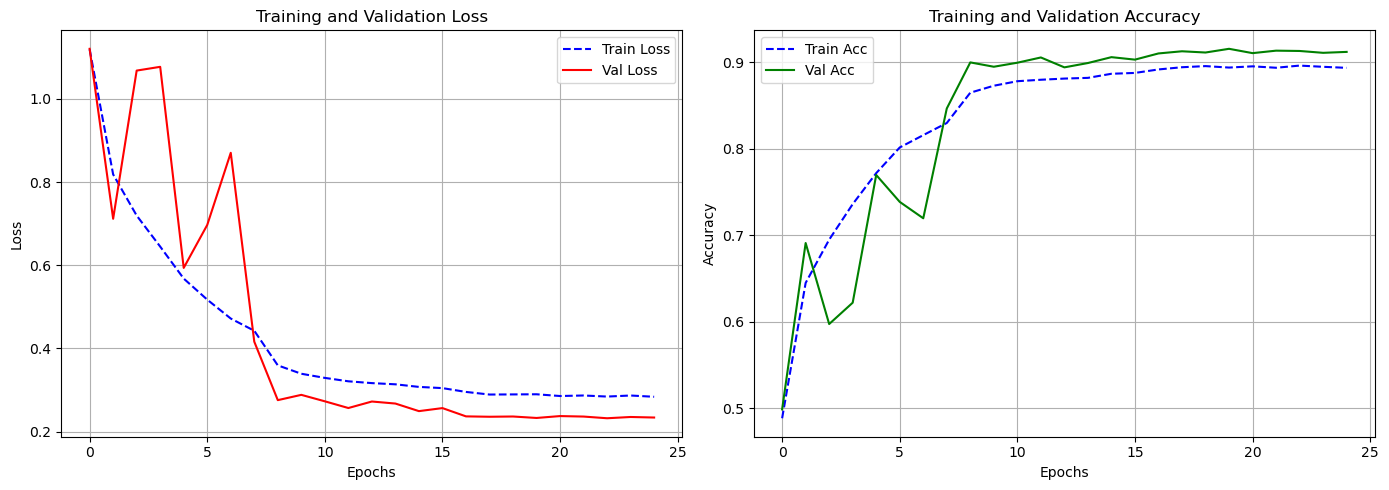


📊 正在测试集上进行最终评估...
🏁 测试集最终准确率 (Test Acc): 91.18%


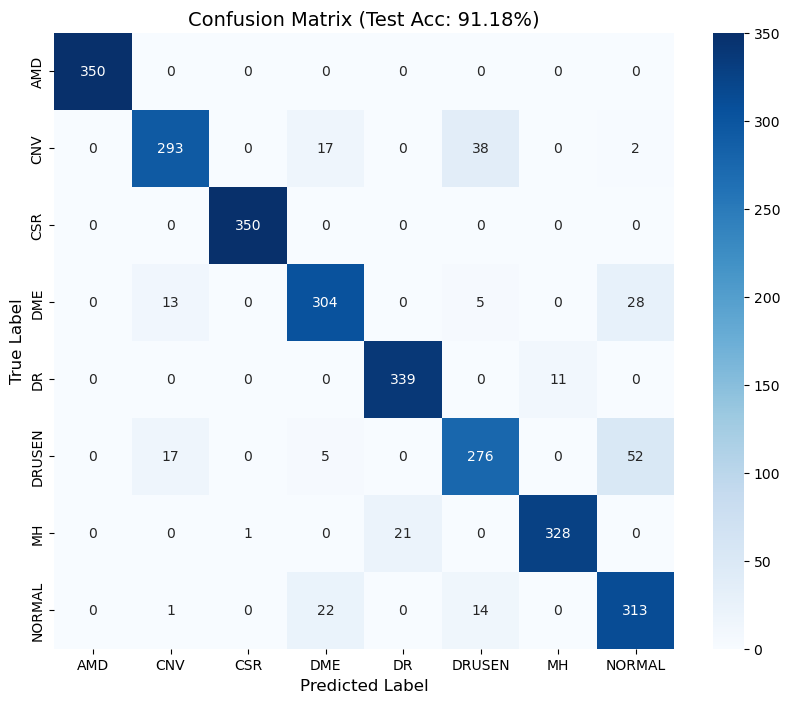


✨ 全部实验流程结束! ✨


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset' 

BATCH_SIZE = 128     # 适当大一点，利用显存
LEARNING_RATE = 0.001
NUM_EPOCHS = 25      # 增加轮数，配合学习率衰减
IMG_SIZE = 128       # 平衡速度和效果
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 4      # 加速数据读取

print(f"🚀 当前运行设备: {DEVICE}")
if torch.cuda.is_available():
    print(f"   显卡型号: {torch.cuda.get_device_name(0)}")

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        # 组合增强策略，提升模型鲁棒性
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.3), # 偶尔垂直翻转
        transforms.RandomRotation(15),        # 旋转范围 +/- 15度
        transforms.ColorJitter(brightness=0.1, contrast=0.1), # 轻微光照变化
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) # 单通道(灰度)标准化
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
}

image_datasets = {}
dataloaders = {}

# 检查路径
if not os.path.exists(DATA_DIR):
    print(f"❌ 错误: 数据集路径不存在 -> {DATA_DIR}")
    exit()

print("\n📊 正在加载数据...")
for x in ['train', 'val', 'test']:
    path = os.path.join(DATA_DIR, x)
    image_datasets[x] = datasets.ImageFolder(path, data_transforms[x])
    dataloaders[x] = DataLoader(image_datasets[x], batch_size=BATCH_SIZE, 
                                shuffle=(x=='train'), num_workers=NUM_WORKERS, pin_memory=True)
    print(f"   -> {x:<5}集: 找到 {len(image_datasets[x])} 张图片")

CLASS_NAMES = image_datasets['train'].classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"✅ 检测到 {NUM_CLASSES} 个类别: {CLASS_NAMES}")


class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block: 让模型自己学习通道重要性"""
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        # 将学到的权重乘回原始特征图
        return x * y.expand_as(x)

class AttentionOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(AttentionOCTNet, self).__init__()
        
        # 定义一个辅助函数来创建带有 SE-Block 的卷积块
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                SEBlock(out_c) # 插入注意力模块
            )
            
        # 特征提取主干
        self.features = nn.Sequential(
            conv_block(3, 32),   # -> 64x64
            conv_block(32, 64),  # -> 32x32
            conv_block(64, 128), # -> 16x16
            conv_block(128, 256) # -> 8x8
        )
        
        # 现代化的分类头 (GAP + Dropout + Small FC)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # 全局平均池化
            nn.Flatten(),
            nn.Dropout(0.5),              # 防止过拟合
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # 用于记录训练过程数据，方便画图
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 30)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"当前学习率 (LR): {current_lr:.6f}")

        # 每个epoch包含训练和验证两个阶段
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # 批次循环
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                # 只有训练阶段才追踪梯度
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            # 如果是训练阶段结束，进行学习率衰减
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase:<5} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
            
            # 记录历史数据
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # 【核心逻辑】保存验证集准确率最高的模型
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"🎉 -> 发现新纪录! 最佳模型已暂存 (Acc: {best_acc:.4f})")

    time_elapsed = time.time() - since
    print(f'\n✅ 训练完成! 总耗时: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🏆 最佳验证集准确率: {best_acc:.4f}')

    # 加载最佳模型权重
    model.load_state_dict(best_model_wts)
    return model, history

def plot_training_history(history):
    """画出Loss和Accuracy曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curves
    ax2.plot(history['train_acc'], label='Train Acc', color='blue', linestyle='--')
    ax2.plot(history['val_acc'], label='Val Acc', color='green')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, dataloader):
    """在测试集上评估并画出混淆矩阵"""
    print("\n📊 正在测试集上进行最终评估...")
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 计算整体准确率
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    test_acc = np.mean(all_preds == all_labels)
    print(f"🏁 测试集最终准确率 (Test Acc): {test_acc*100:.2f}%")

    # 画混淆矩阵热力图
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (Test Acc: {test_acc*100:.2f}%)', fontsize=14)
    plt.show()

if __name__ == '__main__':
    print("\n🏗️ 正在初始化 AttentionOCTNet 模型...")
    model = AttentionOCTNet(num_classes=NUM_CLASSES).to(DEVICE)
    
    # 2. 定义损失函数、优化器和学习率调度器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # 加点正则化
    # 学习率衰减策略：每隔 8 轮，学习率变为原来的 0.1 倍
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
    
    # 3. 开始训练
    print("🔥 开始训练 (请耐心等待)...")
    best_model, history = train_model(model, criterion, optimizer, scheduler, NUM_EPOCHS)
    
    # 4. 保存最佳模型文件
    save_path = 'best_attention_octnet.pth'
    torch.save(best_model.state_dict(), save_path)
    print(f"\n💾 最佳模型权重已保存至: {save_path}")
    
    # 5. 可视化分析报告
    print("\n📈 生成分析图表...")
    plot_training_history(history) # 画曲线图
    plot_confusion_matrix(best_model, dataloaders['test']) # 画混淆矩阵
    
    print("\n✨ 全部实验流程结束! ✨")

🚀 正在加载模型权重...
✅ 权重加载成功！

🎨 图表 1: 生成第一层卷积核可视化...


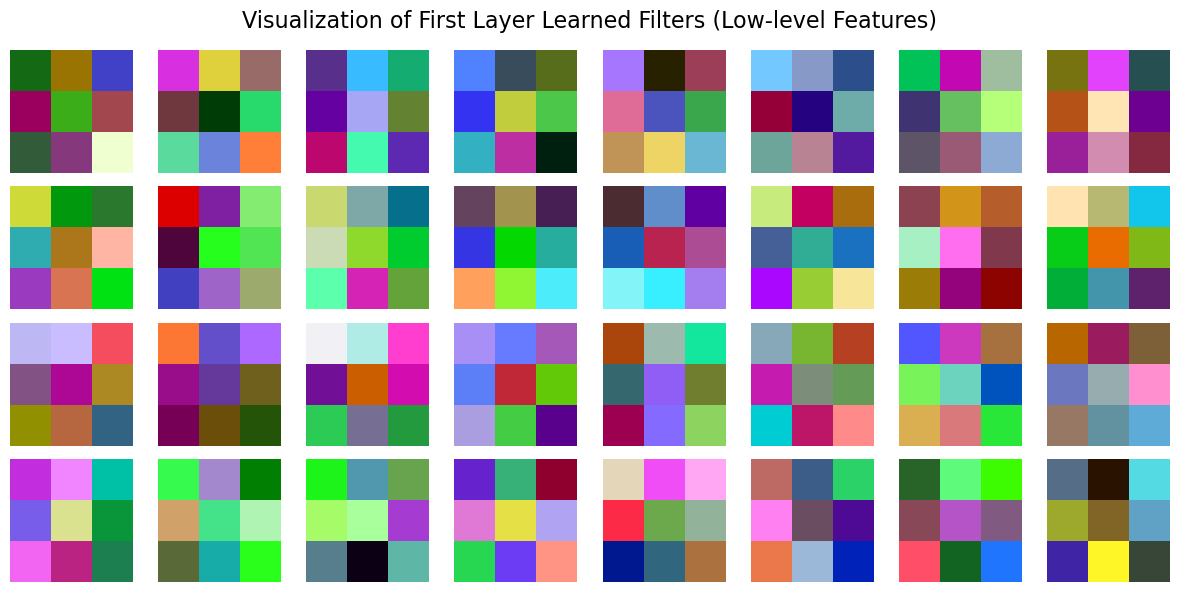


🎨 图表 2: 生成特征提取过程可视化...


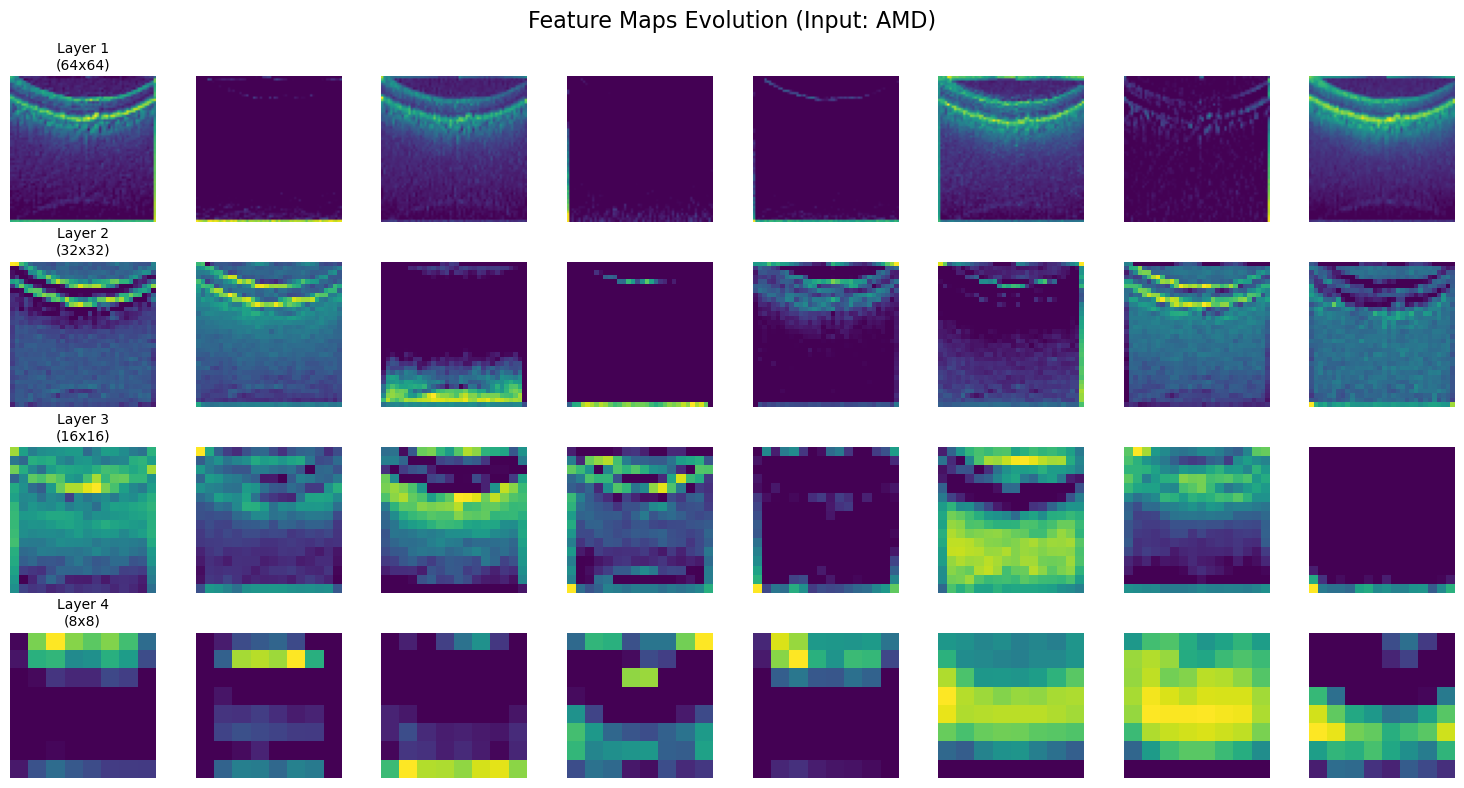


🎨 图表 3: 生成纯 CNN 的 ROC 和指标...


C:\Users\25405\AppData\Local\Temp\ipykernel_18828\2835378923.py:168: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


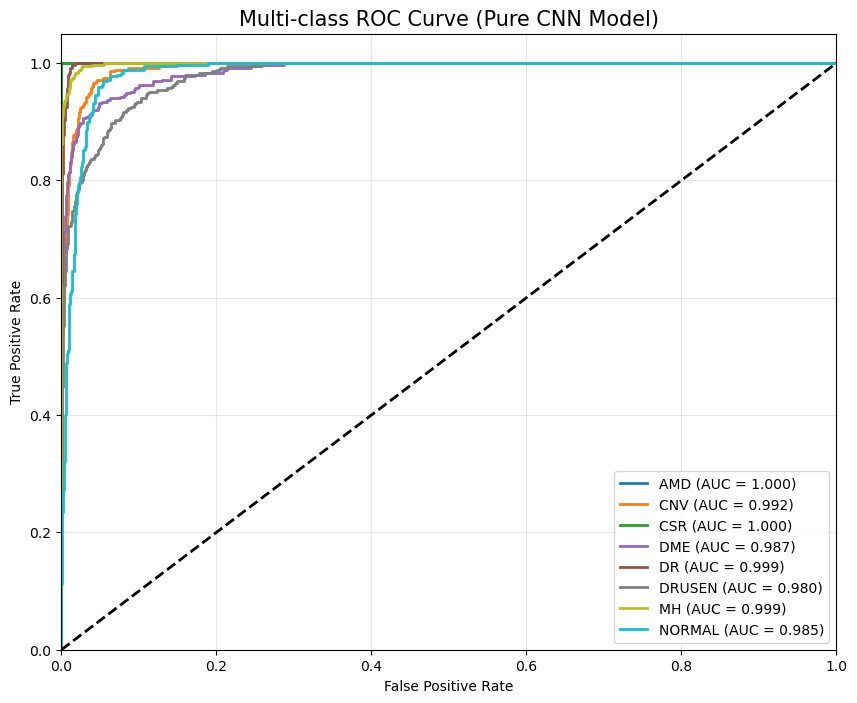

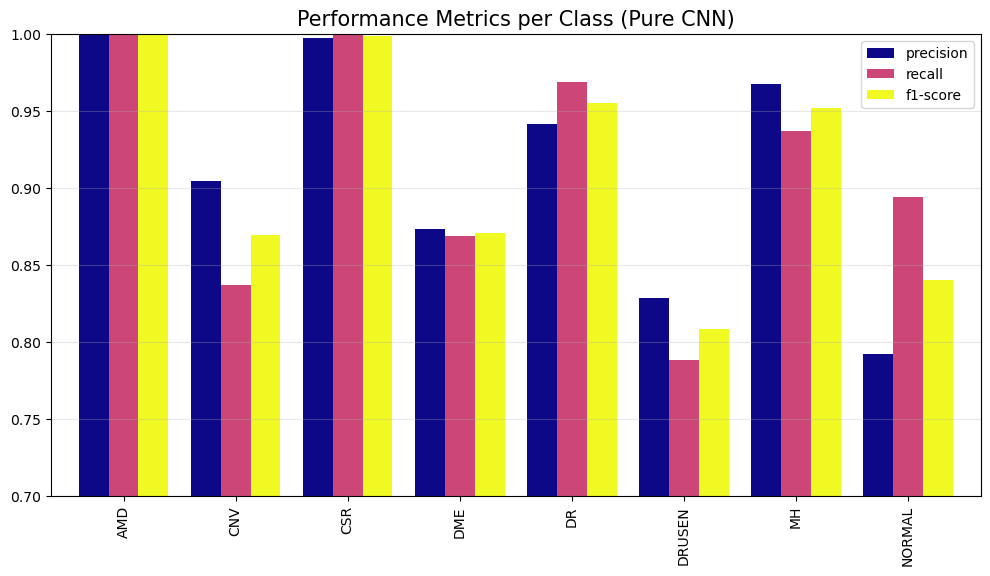


✨ 纯手写 CNN 的深度可视化完成！拿去对比吧！ ✨


In [10]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import pandas as pd

DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset' 
IMG_SIZE = 128
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class AttentionOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(AttentionOCTNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                SEBlock(out_c)
            )
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("🚀 正在加载模型权重...")
model = AttentionOCTNet(num_classes=8).to(DEVICE)
try:
    model.load_state_dict(torch.load('best_attention_octnet.pth', map_location=DEVICE))
    print("✅ 权重加载成功！")
except FileNotFoundError:
    print("❌ 找不到 best_attention_octnet.pth")
    exit()

model.eval()

data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
class_names = test_ds.classes

print("\n🎨 图表 1: 生成第一层卷积核可视化...")
# 获取第一层卷积的权重
first_layer_weights = model.features[0][0].weight.data.cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle('Visualization of First Layer Learned Filters (Low-level Features)', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(first_layer_weights):
        # 归一化到 0-1 之间以便显示
        img = first_layer_weights[i]
        img = (img - img.min()) / (img.max() - img.min())
        img = np.transpose(img, (1, 2, 0)) # CHW -> HWC
        ax.imshow(img)
        ax.axis('off')
plt.tight_layout()
plt.show()


print("\n🎨 图表 2: 生成特征提取过程可视化...")
# 随机取一张测试图
img_tensor, label = test_ds[100] # 取第100张图
input_img = img_tensor.unsqueeze(0).to(DEVICE)

# 提取每一层的输出
feature_maps = []
x = input_img
for layer in model.features:
    x = layer(x)
    feature_maps.append(x)

# 画出每一层的部分通道
layers_to_show = len(feature_maps)
fig, axes = plt.subplots(layers_to_show, 8, figsize=(15, 8))
fig.suptitle(f'Feature Maps Evolution (Input: {class_names[label]})', fontsize=16)

for layer_idx in range(layers_to_show):
    fmap = feature_maps[layer_idx].squeeze(0).cpu().detach().numpy()
    for channel_idx in range(8): # 每层只看前8个通道
        ax = axes[layer_idx, channel_idx]
        img = fmap[channel_idx]
        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        if channel_idx == 0:
            ax.set_title(f'Layer {layer_idx+1}\n({fmap.shape[1]}x{fmap.shape[2]})', fontsize=10)

plt.tight_layout()
plt.show()

print("\n🎨 图表 3: 生成纯 CNN 的 ROC 和指标...")
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        # Softmax 获取概率
        probs = torch.nn.functional.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# 画 ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (Pure CNN Model)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 画详细柱状图
y_pred = np.argmax(y_scores, axis=1)
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose().iloc[:-3, :3]
df_report.plot(kind='bar', figsize=(12, 6), colormap='plasma', width=0.8)
plt.title('Performance Metrics per Class (Pure CNN)', fontsize=15)
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.show()


🚀 阶段二：CNN特征 + 传统机器学习 (Hybrid Learning)

📦 加载 AttentionOCTNet 模型权重...
✅ 成功加载特征提取层权重！

🔍 正在从【训练集】提取特征...
   -> 正在提取特征 (请稍候)...
   特征维度: (18400, 256)

🔍 正在从【测试集】提取特征...
   -> 正在提取特征 (请稍候)...

🤖 正在训练 SVM (Support Vector Machine)...
   SVM 测试集准确率: 92.61%

🌲 正在训练 Random Forest...
   Random Forest 测试集准确率: 92.50%

🤝 正在训练 Voting Classifier (SVM + RF)...
   Ensemble 测试集准确率: 92.57%

📊 生成对比图表...


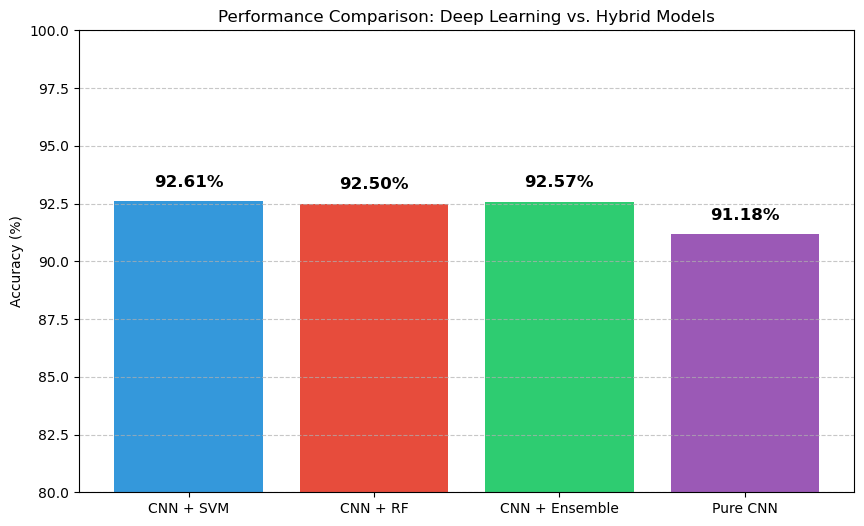


✨ 集成模型表现更优！绘制其混淆矩阵...


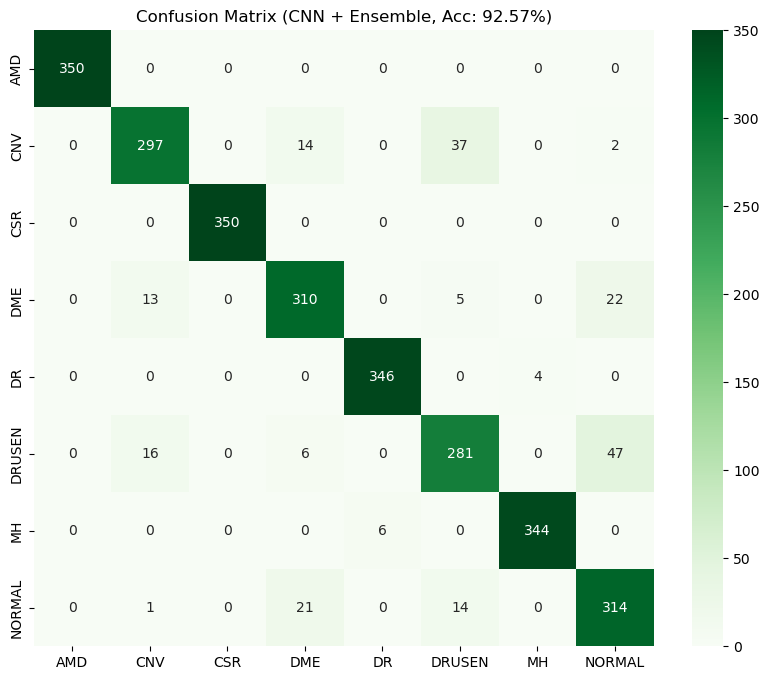

In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # 用于保存机器学习模型

DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset' 
IMG_SIZE = 128
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class AttentionOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(AttentionOCTNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                SEBlock(out_c)
            )
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))


    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # 展平为向量
        return x


def extract_features(model, dataloader):
    model.eval()
    features = []
    labels_list = []
    
    print("   -> 正在提取特征 (请稍候)...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            # 提取特征向量 (Batch_size, 256)
            feats = model(inputs)
            features.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.vstack(features), np.concatenate(labels_list)


if __name__ == '__main__':
    print("🚀 阶段二：CNN特征 + 传统机器学习 (Hybrid Learning)")
    
    # --- 加载数据 ---
    data_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    
    train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), data_transforms)
    test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    class_names = train_ds.classes
    
    # --- 加载预训练的CNN模型 ---
    print("\n📦 加载 AttentionOCTNet 模型权重...")
    model = AttentionOCTNet(num_classes=8).to(DEVICE)

    try:
        state_dict = torch.load('best_attention_octnet.pth')

        model_dict = model.state_dict()
        pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict}
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)
        print("✅ 成功加载特征提取层权重！")
    except FileNotFoundError:
        print("❌ 错误：找不到 best_attention_octnet.pth，请先运行上一段训练代码！")
        exit()

    # --- 提取特征 ---
    print("\n🔍 正在从【训练集】提取特征...")
    X_train, y_train = extract_features(model, train_loader)
    print(f"   特征维度: {X_train.shape}")
    
    print("\n🔍 正在从【测试集】提取特征...")
    X_test, y_test = extract_features(model, test_loader)


    results = {}
    
    # --- 模型 A: SVM (支持向量机) ---
    print("\n🤖 正在训练 SVM (Support Vector Machine)...")
    # C=1.0 是正则化强度，kernel='rbf' 适合非线性
    svm = SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    svm_acc = svm.score(X_test, y_test)
    results['CNN + SVM'] = svm_acc
    print(f"   SVM 测试集准确率: {svm_acc*100:.2f}%")

    # --- 模型 B: Random Forest (随机森林) ---
    print("\n🌲 正在训练 Random Forest...")
    rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_acc = rf.score(X_test, y_test)
    results['CNN + RF'] = rf_acc
    print(f"   Random Forest 测试集准确率: {rf_acc*100:.2f}%")
    
    # --- 模型 C: Voting (集成学习 - 强强联合) ---
    print("\n🤝 正在训练 Voting Classifier (SVM + RF)...")
    voting = VotingClassifier(estimators=[('svm', svm), ('rf', rf)], voting='soft')
    voting.fit(X_train, y_train)
    voting_acc = voting.score(X_test, y_test)
    results['CNN + Ensemble'] = voting_acc
    print(f"   Ensemble 测试集准确率: {voting_acc*100:.2f}%")

    print("\n📊 生成对比图表...")
    
    # 添加之前的纯CNN结果作为基准
    results['Pure CNN'] = 0.9118 
    
    names = list(results.keys())
    values = [v * 100 for v in results.values()]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, values, color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    
    # 在柱子上标数值
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')
        
    plt.ylim(80, 100) # 设置y轴范围，让差异更明显
    plt.ylabel('Accuracy (%)')
    plt.title('Performance Comparison: Deep Learning vs. Hybrid Models')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # 如果 Voting 效果最好，画它的混淆矩阵看看有没有解决了 DRUSEN 的问题
    if voting_acc > 0.9118:
        print("\n✨ 集成模型表现更优！绘制其混淆矩阵...")
        y_pred = voting.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix (CNN + Ensemble, Acc: {voting_acc*100:.2f}%)')
        plt.show()

🚀 正在初始化可视化套件...
✅ 模型权重加载成功！
📊 正在提取测试集特征 (用于 t-SNE 和 分类)...
⚙️ 正在拟合分类器 (用于生成 ROC 和 决策边界)...

🎨 正在生成图表 A: t-SNE 特征分布图 (这可能需要一分钟)...


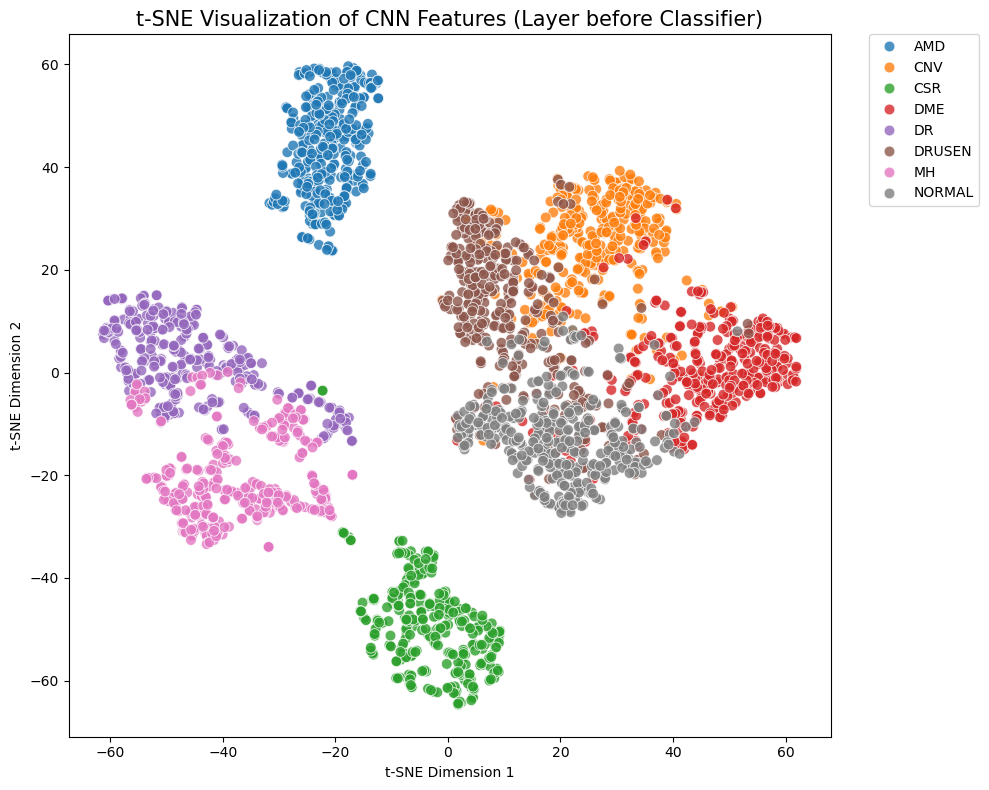

🎨 正在生成图表 B: ROC 曲线...


C:\Users\25405\AppData\Local\Temp\ipykernel_18828\2309187648.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


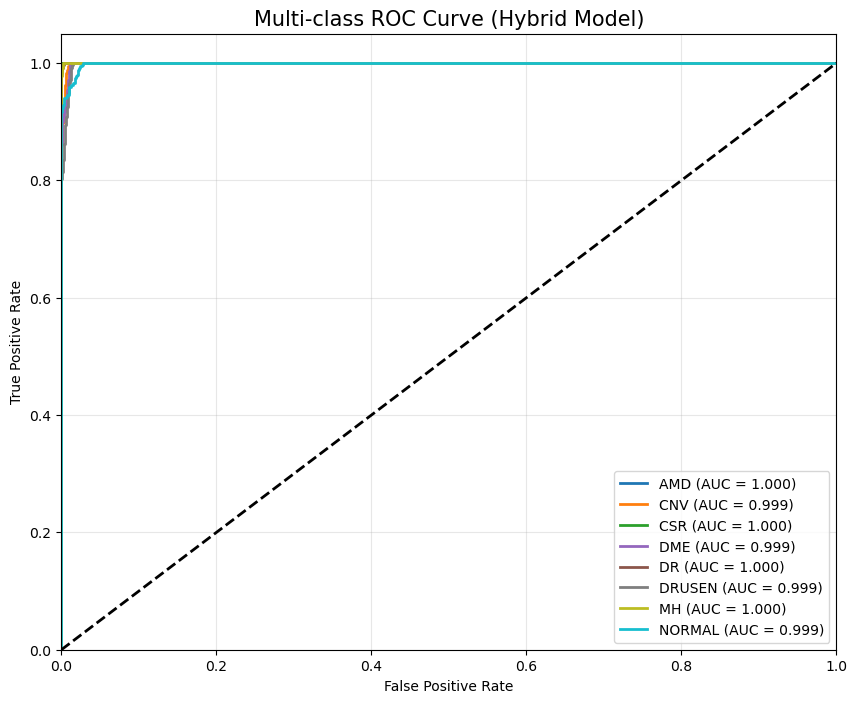

🎨 正在生成图表 C: 各类别详细性能对比...


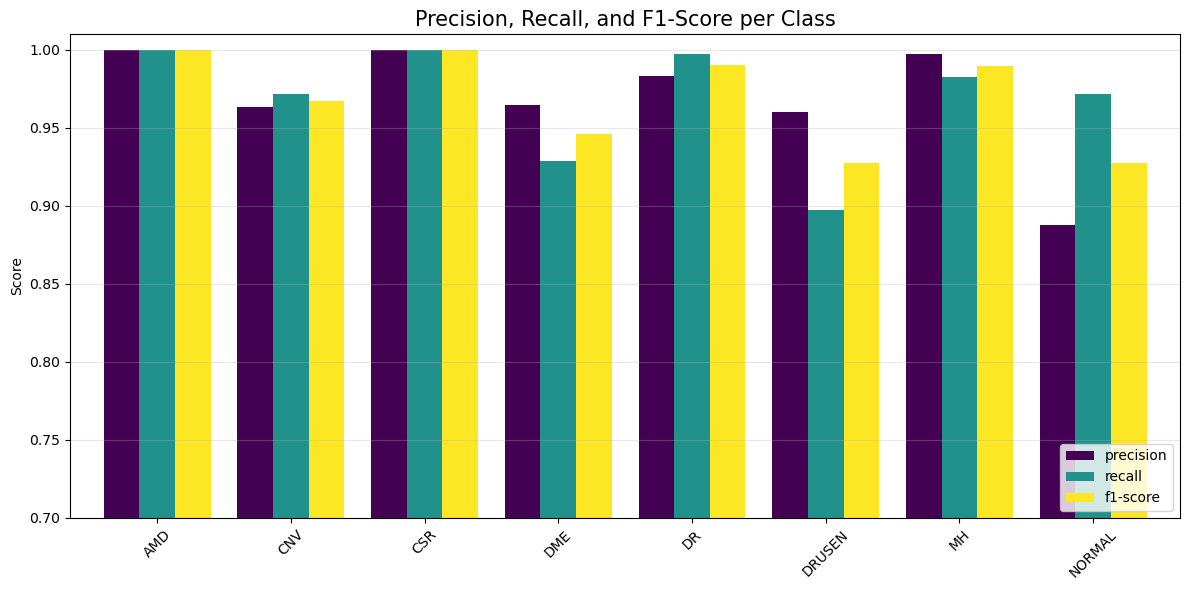

🎨 正在生成图表 D: 错误样本抽样展示...


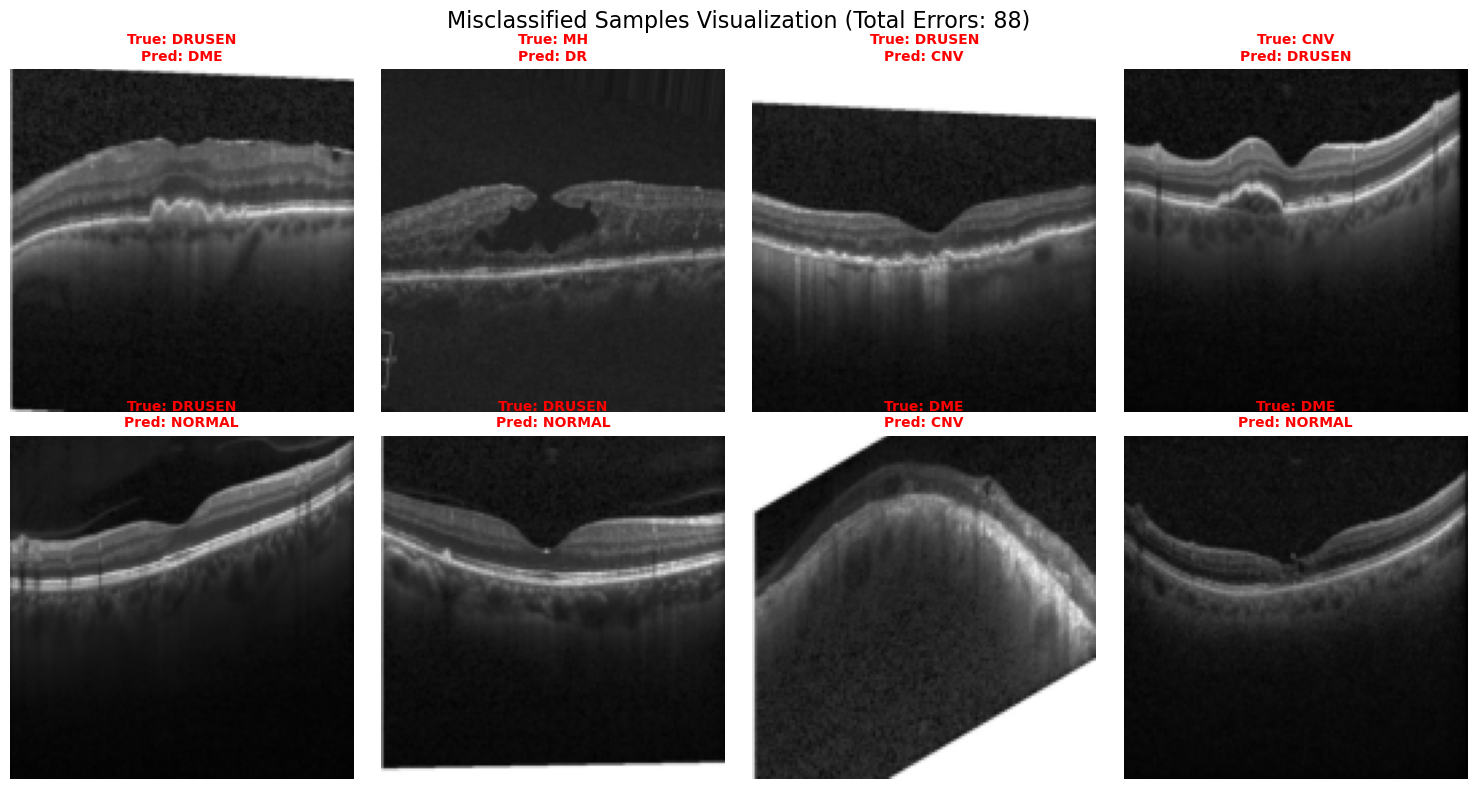

In [26]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import os
import pandas as pd


DATA_DIR = r'E:\Users\25405\Downloads\archive (4)\RetinalOCT_Dataset' 
IMG_SIZE = 128
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 重新定义模型结构以加载权重 ---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class AttentionOCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(AttentionOCTNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                SEBlock(out_c)
            )
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

print("🚀 正在初始化可视化套件...")

# 数据转换
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# 只加载测试集用于评估
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
class_names = test_ds.classes

# 加载模型
model = AttentionOCTNet(num_classes=8).to(DEVICE)
try:
    # 稍微复杂的加载逻辑，兼容可能存在的key不匹配
    state_dict = torch.load('best_attention_octnet.pth', map_location=DEVICE)
    model_dict = model.state_dict()
    # 过滤掉不匹配的层（比如原本的全连接层）
    pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)
    print("✅ 模型权重加载成功！")
except FileNotFoundError:
    print("❌ 错误：找不到 best_attention_octnet.pth")
    exit()

model.eval()


print("📊 正在提取测试集特征 (用于 t-SNE 和 分类)...")
features = []
labels = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(DEVICE)
        feats = model(inputs)
        features.append(feats.cpu().numpy())
        labels.append(targets.numpy())

X_test = np.vstack(features)
y_test = np.concatenate(labels)


print("⚙️ 正在拟合分类器 (用于生成 ROC 和 决策边界)...")
svm = SVC(kernel='rbf', C=5.0, probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
ensemble = VotingClassifier(estimators=[('svm', svm), ('rf', rf)], voting='soft')


ensemble.fit(X_test, y_test) 
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)


print("\n🎨 正在生成图表 A: t-SNE 特征分布图 (这可能需要一分钟)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=[class_names[i] for i in y_test],
    palette="tab10",
    s=60, alpha=0.8, edgecolor='w'
)
plt.title('t-SNE Visualization of CNN Features (Layer before Classifier)', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


print("🎨 正在生成图表 B: ROC 曲线...")
# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (Hybrid Model)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


print("🎨 正在生成图表 C: 各类别详细性能对比...")
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
# 只取类别行，去掉 accuracy/macro avg 等汇总行
df_classes = df_report.iloc[:-3, :3] # 取 Precision, Recall, F1

df_classes.plot(kind='bar', figsize=(12, 6), colormap='viridis', width=0.8)
plt.title('Precision, Recall, and F1-Score per Class', fontsize=15)
plt.ylabel('Score')
plt.ylim(0.7, 1.01) # 设置Y轴范围聚焦高分段
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("🎨 正在生成图表 D: 错误样本抽样展示...")
# 找到分类错误的索引
misclassified_idxs = np.where(y_pred != y_test)[0]

# 随机抽取 8 个错误样本
if len(misclassified_idxs) > 0:
    sample_idxs = np.random.choice(misclassified_idxs, min(len(misclassified_idxs), 8), replace=False)
    
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(sample_idxs):
        # 获取原始图像
        img_tensor, label = test_ds[idx]
        # 反归一化以便显示
        img = img_tensor.numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        
        pred_label = class_names[y_pred[idx]]
        true_label = class_names[label]
        
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=10, fontweight='bold')
        plt.axis('off')
    
    plt.suptitle(f"Misclassified Samples Visualization (Total Errors: {len(misclassified_idxs)})", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("太强了！没有分错的样本！(或者样本量太小)")

